# Faza 1: Raziskovalna analiza podatkov in predprocesiranje

**Zastavljen cilj**: Razumeti in vizualizirati statistične lastnosti podatkov ter v celoti pripraviti očiščeno, transformirano in skalirano numerično bazo brez manjkajočih vrednosti. Ta faza je ključna za uspešno uporabo nevronskih mrež in algoritma XGBoost v nadaljevanju.

Pomembno opozorilo: Celotno predprocesiranje (imputacija in skaliranje) smo "naučili" (*fit*) izključno na učni (train) množici. Naučene transformacije smo nato aplicirali (*transform*) na učno in na testno množico, s čimer smo strogo preprečili uhajanje informacij (ang. *Data Leakage*).

## 1. Uvoz knjižnic in nalaganje podatkov

Najprej smo uvozili orodja za vizualizacijo (`matplotlib`, `seaborn`) in knjižnice za strojno učenje. Naložili smo učno in testno množico iz prejšnje faze.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import os

# TODO (ekipa): Naložite `../data/train_raw.csv` v obliko `train_df` in `../data/test_raw.csv` v `test_df`.
# TODO (ekipa): Za namene raziskovalne analize (EDA) bomo v prvem delu uporabljali samo `train_df`!

train_df = pd.read_csv('../data/train_raw.csv')
test_df = pd.read_csv('../data/test_raw.csv')

## 2. Raziskovalna analiza podatkov (EDA)
Raziskovalno analizo smo izvedli zgolj na naboru za učenje, da ne bi pristransko vplivali na naše odločitve.

### 2.1 Manjkajoče vrednosti in porazdelitev ciljne spremenljivke
Preverili smo količino in strukturo manjkajočih podatkov ter osnovno porazdelitev razredov pri naši ciljni spremenljivki `loan_status`.

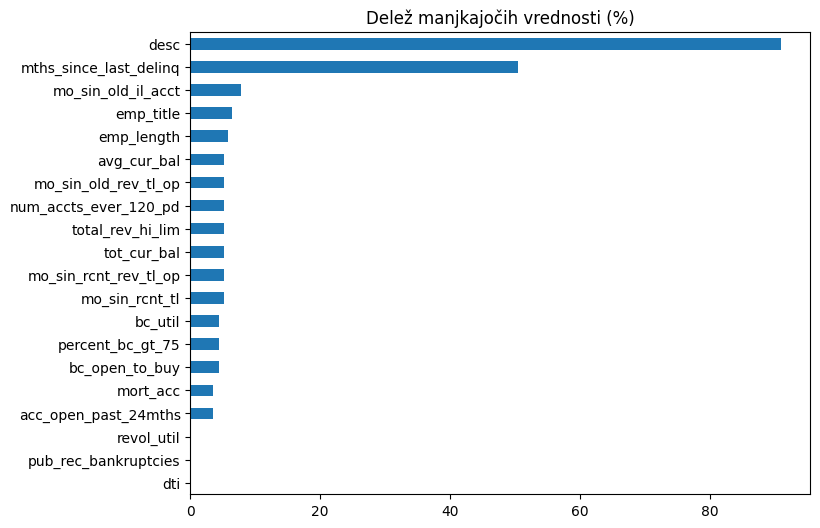

In [2]:
# TODO (ekipa): Prikažite graf manjkajočih vrednosti (npr. s seaborn heatmap nad vrsticami z isnull() ali bar chart z manjkajočimi odstotki na stolpec).
# TODO (ekipa): Narišite bar chart za ciljno spremenljivko `loan_status`. Prikažite in zapišite odstotek razreda 1 (stopnja neplačil oz. default rate).
# Manjkajoče vrednosti
missing = train_df.isnull().mean()*100

missing[missing>0].sort_values().plot.barh(figsize=(8,6))
plt.title("Delež manjkajočih vrednosti (%)")
plt.show()

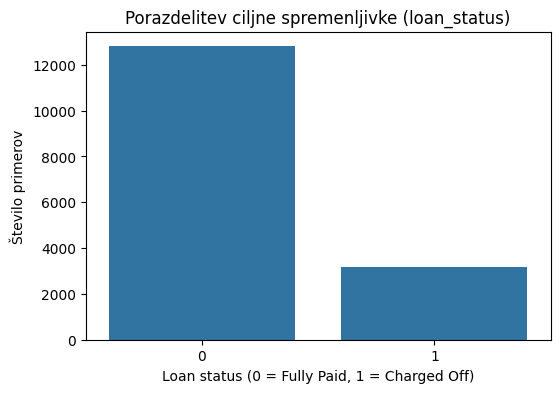

Stopnja neplačil (default rate): 19.96%


In [3]:
# Bar chart za loan_status
plt.figure(figsize=(6,4))
sns.countplot(x='loan_status', data=train_df)
plt.title("Porazdelitev ciljne spremenljivke (loan_status)")
plt.xlabel("Loan status (0 = Fully Paid, 1 = Charged Off)")
plt.ylabel("Število primerov")
plt.show()

default_rate = train_df['loan_status'].mean() * 100
print(f"Stopnja neplačil (default rate): {default_rate:.2f}%")

### 2.2 Porazdelitev ključnih značilk glede na neplačilo
V nadaljevanju dmo raziskali, kako se ključne značilnosti posojil in posojilojemalcev razlikujejo, glede na to, ali je bilo posojilo poplačano ali ne. 
Uporabili smo prekrivajoče se histograme in škatle z brki (boxplots) za prikazane atribute.

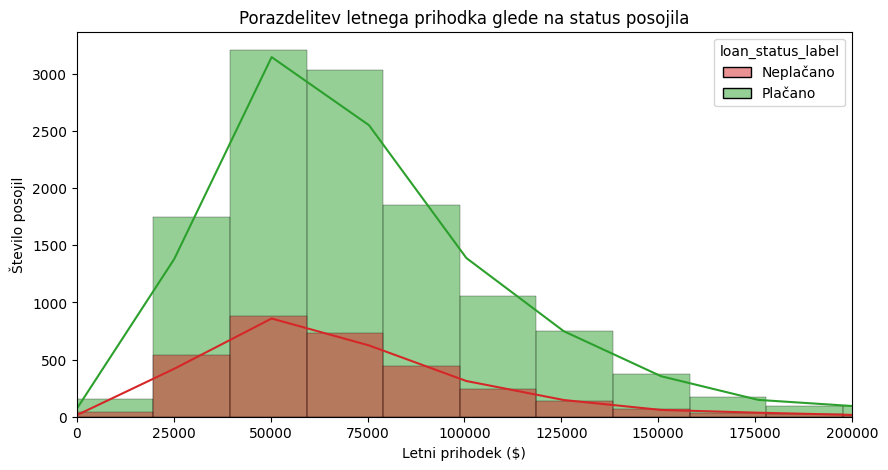

In [4]:
# TODO (ekipa): Narišite histograme/KDE plots z ločenimi barvami (hue='loan_status') za `annual_inc`, `dti`, `int_rate`, `fico_range_low` in `revol_util`.
# TODO (ekipa): Komentirajte ugotovitve (npr. 'Višja obrestna mera je očitno prisotna pri neplačnikih').
# TODO (ekipa): Narišite stolpične diagrame deleža neplačil (default rate) glede na kategorične značilke `grade`, `home_ownership` in `purpose`.

# Letni dohodek
train_df['loan_status_label'] = train_df['loan_status'].map({0: 'Plačano', 1: 'Neplačano'})

# Histogram z ločenimi barvami po statusu
plt.figure(figsize=(10,5))
sns.histplot(data=train_df, x='annual_inc', hue='loan_status_label', kde=True, palette=['#d62728','#2ca02c'])
plt.xlim(0, 200000)
plt.title("Porazdelitev letnega prihodka glede na status posojila")
plt.xlabel("Letni prihodek ($)")
plt.ylabel("Število posojil")
plt.show()

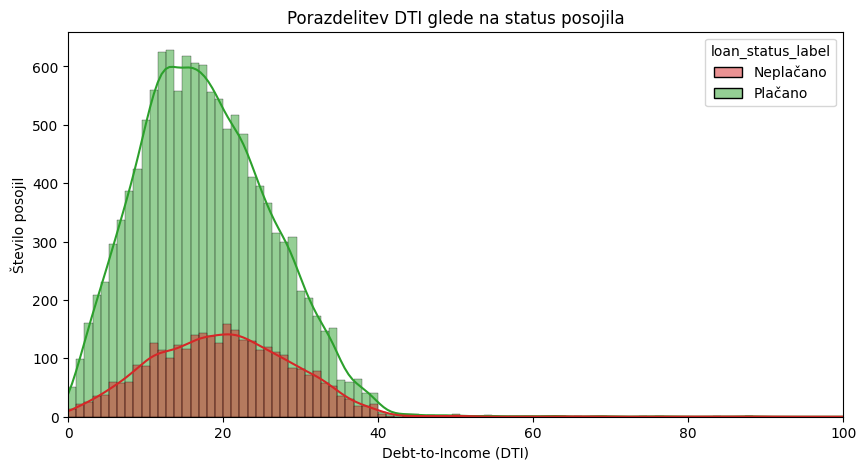

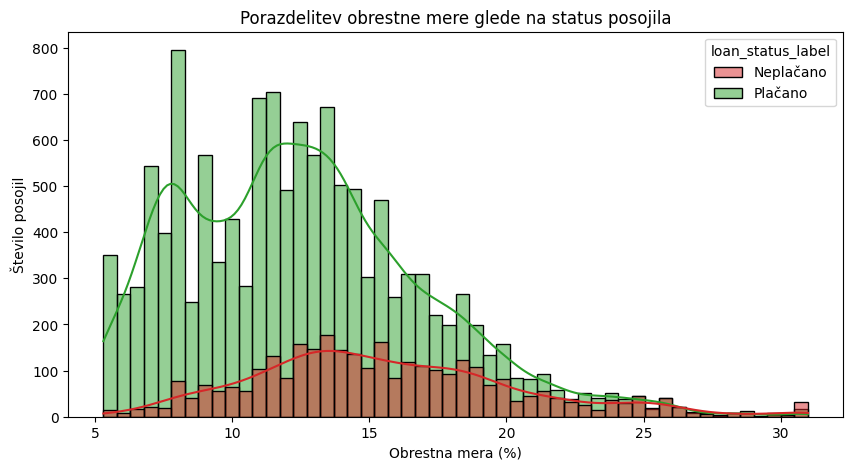

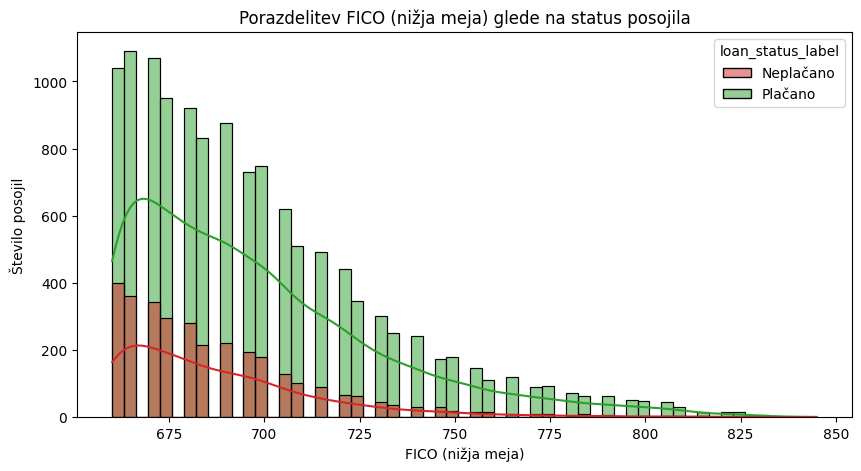

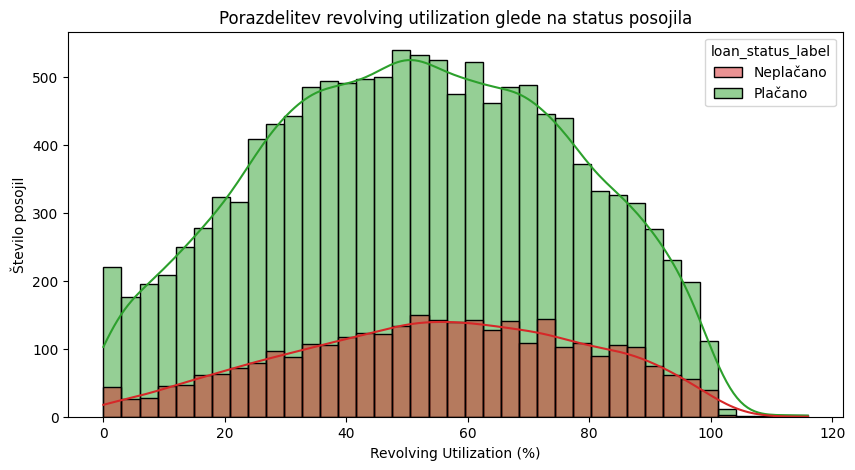

In [5]:
# Dodamo labelo za bolj razumljiv prikaz
train_df['loan_status_label'] = train_df['loan_status'].map({0: 'Plačano', 1: 'Neplačano'})

colors = ['#d62728','#2ca02c']

# 1. DTI
plt.figure(figsize=(10,5))
sns.histplot(data=train_df, x='dti', hue='loan_status_label', kde=True, palette=colors, kde_kws={'clip': (0, 100)})
plt.title("Porazdelitev DTI glede na status posojila")
plt.xlabel("Debt-to-Income (DTI)")
plt.ylabel("Število posojil")
plt.xlim(0, 100)
plt.show()

# 2. Obrestna mera
plt.figure(figsize=(10,5))
sns.histplot(data=train_df, x='int_rate', hue='loan_status_label', kde=True, palette=colors)
plt.title("Porazdelitev obrestne mere glede na status posojila")
plt.xlabel("Obrestna mera (%)")
plt.ylabel("Število posojil")
plt.show()

# 3. FICO range low
plt.figure(figsize=(10,5))
sns.histplot(data=train_df, x='fico_range_low', hue='loan_status_label', kde=True, palette=colors)
plt.title("Porazdelitev FICO (nižja meja) glede na status posojila")
plt.xlabel("FICO (nižja meja)")
plt.ylabel("Število posojil")
plt.show()

# 4. Revolving utilization
plt.figure(figsize=(10,5))
sns.histplot(data=train_df, x='revol_util', hue='loan_status_label', kde=True, palette=colors)
plt.title("Porazdelitev revolving utilization glede na status posojila")
plt.xlabel("Revolving Utilization (%)")
plt.ylabel("Število posojil")
plt.show()

Letni prihodek (annual_inc): Večina posojil je odobrenih osebam s srednjim dohodkom, saj je teh največ, revnim posojil ne odobrijo, bogati pa imajo nižjo stopnjo neplačil.

Razmerje dolg/dohodek (dti): Vrednost 40 % predstavlja zgornjo mejo za odobritev posojila, saj banke pri višjih vrednostih ocenjujejo, da posojilojemalec ne bo zmogel odplačevati.

Obrestna mera (int_rate): Osebe z nizko obrestno mero nimajo težav z odplačevanjem, medtem ko je pri visoki obrestni meri delež neplačil bistveno večji.

Kreditni rezultat (FICO): Osebe z visokim FICO redno odplačujejo svoje obroke, kar potrjuje, da je to dober pokazatelj kreditne sposobnosti.

Izkoristek kreditnih kartic (revolving utilization): Visoka vrednost predstavlja zanesljiv rdeči alarm, saj kaže na finančno stisko in visoko verjetnost neplačila.

### 2.3 Korelacije in prisotnost besedilnih polj
Raziskali smo medsebojne linearne korelacije med numeričnimi vrednostmi ter preverili, koliko podatkov vsebuje prave opise posojil (stolpca `desc` in `emp_title`).

In [6]:
# TODO (ekipa): Narišite korelacijsko matriko (seaborn heatmap) za vse numerične atribute.
# TODO (ekipa): Izračunajte odstotek vrstic, ki IMAJO izpolnjeno polje `desc`, in tistih, ki imajo `emp_title`. 
# (Kot pojasnjeno v načrtu, `desc` pričakujemo okrog ~5 %, `emp_title` pa zelo visoko).

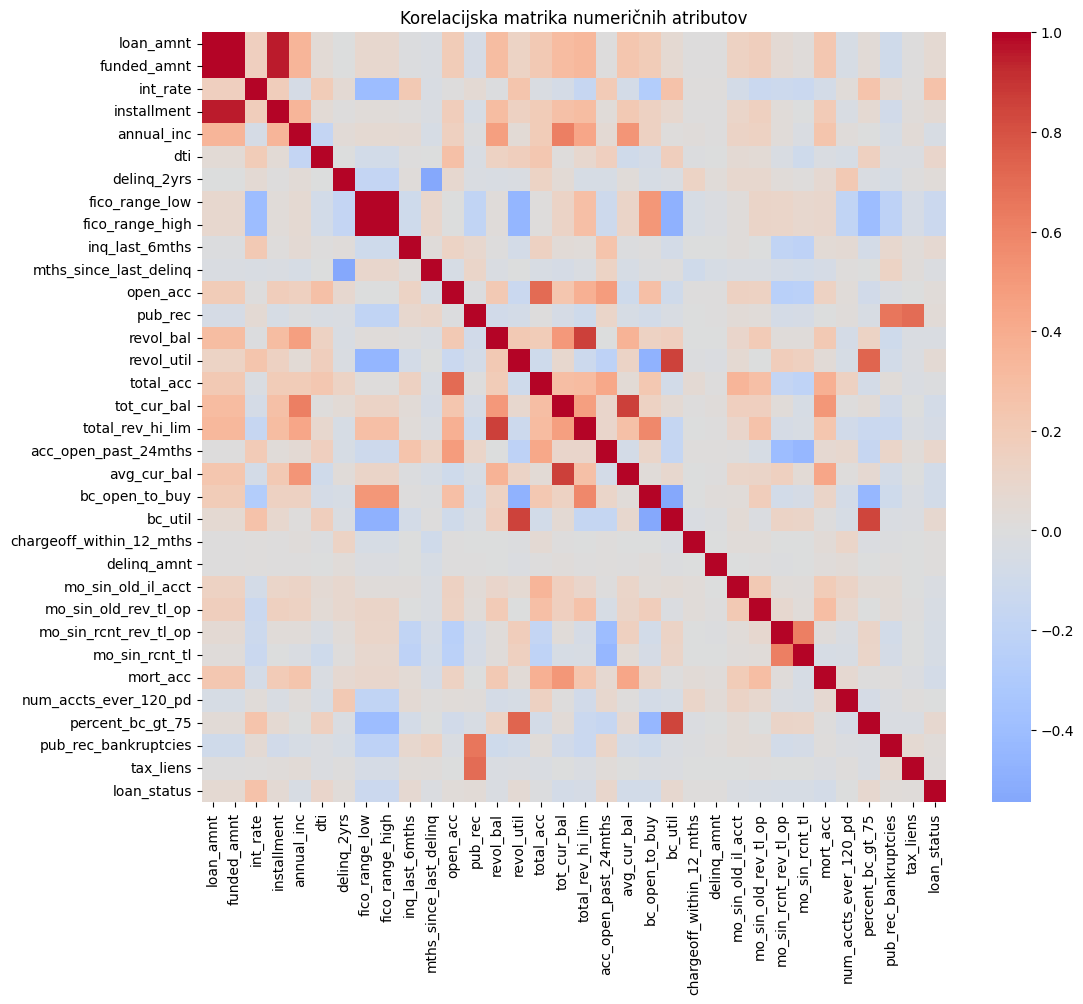

Delež vrstic z opisom (desc): 9.03%
Delež vrstic z nazivom delovnega mesta (emp_title): 93.64%


In [7]:
numeric_df = train_df.select_dtypes(include=['int64','float64'])

# Korelacijska matrika
corr_matrix = numeric_df.corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0)
plt.title("Korelacijska matrika numeričnih atributov")
plt.show()

# odstotek vrstic z desc
desc_percent = train_df['desc'].notna().mean() * 100
# odstotek vrstic z emp_title
emp_title_percent = train_df['emp_title'].notna().mean() * 100

print(f"Delež vrstic z opisom (desc): {desc_percent:.2f}%")
print(f"Delež vrstic z nazivom delovnega mesta (emp_title): {emp_title_percent:.2f}%")

Lahko vidimo da smo res dobili vrednosti ki smo jih načrtovali z manjšim odstopanjem opisov je dejansko 9% naziv delovnega mesta pa je zelo visok delež kar 93,64%.

## 3. Predprocesiranje podatkov (Imputacija manjkajočih vrednosti)

Obdelavo smo zastavili skrbno: pravila smo definirali in statistike izračunali na učni množici, nato pa enaka pravila aplicirali še na testno.
1. **Numerične spremenljivke**: Vrednosti z manjšim deležem manjkajočih smo nadomestili z mediano. Odstranili smo morebitne stolpce, ki bi imeli >50% manjajočih vrednosti.
2. **Čas in meseci (`mths_since_last_delinq`)**: Odsotnost vrednosti tu pomeni, da dogodka ni bilo. Teh nismo kar zavrgli; ustvarili smo binarno zastavico `had_delinquency` in nato vrednosti nadomestili z mediano.
3. **Besedilo**: NaN v `desc` smo napolnili s praznim nizom (`""`), v `emp_title` pa z oznako `"unknown"`.

In [8]:
# TODO (ekipa): Implementirajte imputacijo nad train in apply nad test.
# - Numerični imputator (SimpleImputer s strategijo 'median').
# - Izdelava zastavice `train_df['had_delinquency'] = train_df['mths_since_last_delinq'].notnull().astype(int)` itd.
# - Zamenjava tekstovnih NaN: `desc` -> "" in `emp_title` -> "unknown".

from sklearn.impute import SimpleImputer


train_df['had_delinquency'] = train_df['mths_since_last_delinq'].notnull().astype(int)
test_df['had_delinquency'] = test_df['mths_since_last_delinq'].notnull().astype(int)


num_cols_all = train_df.select_dtypes(include=['number']).columns
missing_ratio = train_df[num_cols_all].isnull().mean()

cols_to_drop = missing_ratio[missing_ratio > 0.5].index

train_df = train_df.drop(columns=cols_to_drop)
test_df = test_df.drop(columns=cols_to_drop)

num_cols = train_df.select_dtypes(include=['number']).columns

num_cols = num_cols.drop(['had_delinquency'], errors='ignore')

imputer = SimpleImputer(strategy='median')

train_df[num_cols] = imputer.fit_transform(train_df[num_cols])
test_df[num_cols] = imputer.transform(test_df[num_cols])

train_df['desc'] = train_df['desc'].fillna("")
test_df['desc'] = test_df['desc'].fillna("")

train_df['emp_title'] = train_df['emp_title'].fillna("unknown")
test_df['emp_title'] = test_df['emp_title'].fillna("unknown")


print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

print("\nMissing values (top):")
print(train_df.isnull().sum().sort_values(ascending=False).head(10))

print("\nHad delinquency distribution:")
print(train_df['had_delinquency'].value_counts())

Train shape: (16000, 46)
Test shape: (4000, 45)

Missing values (top):
emp_length        932
loan_amnt           0
term                0
int_rate            0
installment         0
funded_amnt         0
grade               0
sub_grade           0
emp_title           0
home_ownership      0
dtype: int64

Had delinquency distribution:
had_delinquency
0    8075
1    7925
Name: count, dtype: int64


## 4. Inženiring značilk (Feature Engineering)

Z namenom boljšega razumevanja podatkov pri modelih (predvsem LR in XGBoost) smo izpeljali vrsto novih naprednih značilk:
- Povezali smo spodnjo in zgornjo FICO mejo v `fico_avg` ter izbrisali originala.
- Datumska polja (kot `earliest_cr_line`) smo pretvorili v numerično vrednost: `credit_history_years` (čas od nastanka do referenčnega datuma recimo leta 2018).
- Ustvarili smo razmerja: `loan_to_income` (višina kredita deljena z letnim prihodkom) in `installment_to_income` (obrok napram mesečnemu prihodku).

In [9]:
# TODO (ekipa): Izračunaj `fico_avg = (fico_range_low + fico_range_high) / 2` in odvrzi prejšnja stolpca (tako za train kot test!).
# TODO (ekipa): Izračunaj `credit_history_years` iz `earliest_cr_line`. Parsiraj string oblik 'Dec-1998' in ugotovi starost. Odvrzi `earliest_cr_line`.
# TODO (ekipa): Ustvari stolpec `loan_to_income` in `installment_to_income`. Pazite na deljenje z 0 (dodajte mikroskopski epsilon k delitelju).


train_df['fico_avg'] = (train_df['fico_range_low'] + train_df['fico_range_high']) / 2
test_df['fico_avg'] = (test_df['fico_range_low'] + test_df['fico_range_high']) / 2

train_df = train_df.drop(columns=['fico_range_low', 'fico_range_high'])
test_df = test_df.drop(columns=['fico_range_low', 'fico_range_high'])

train_df['earliest_cr_line'] = pd.to_datetime(train_df['earliest_cr_line'], format='%b-%Y')
test_df['earliest_cr_line'] = pd.to_datetime(test_df['earliest_cr_line'], format='%b-%Y')

# referenčno leto
ref_date = pd.to_datetime("2018-12-31")

train_df['credit_history_years'] = (ref_date - train_df['earliest_cr_line']).dt.days / 365
test_df['credit_history_years'] = (ref_date - test_df['earliest_cr_line']).dt.days / 365

# drop original
train_df = train_df.drop(columns=['earliest_cr_line'])
test_df = test_df.drop(columns=['earliest_cr_line'])


epsilon = 1e-6

train_df['loan_to_income'] = train_df['loan_amnt'] / (train_df['annual_inc'] + epsilon)
test_df['loan_to_income'] = test_df['loan_amnt'] / (test_df['annual_inc'] + epsilon)

train_df['installment_to_income'] = train_df['installment'] / ((train_df['annual_inc'] / 12) + epsilon)
test_df['installment_to_income'] = test_df['installment'] / ((test_df['annual_inc'] / 12) + epsilon)



In [10]:
#Preverimo da so se ustvarili
new_cols = [
    'fico_avg',
    'credit_history_years',
    'loan_to_income',
    'installment_to_income'
]

print(train_df.columns[train_df.columns.isin(new_cols)])

Index(['fico_avg', 'credit_history_years', 'loan_to_income',
       'installment_to_income'],
      dtype='object')


## 5. Kodiranje kategoričnih spremenljivk

Da se algoritmi uspešno učijo, smo strojne besede morali preslikati v numerične vrednosti:
- **Ordinalne spremenljivke**: `grade` (A=1...G=7), `sub_grade` (A1=1...G5=35), `term` (36 ali 60 v celo število).
- **Dolžina zaposlitve (`emp_length`)**: pretvorili smo v enostavne številke (0 do 10 let), manjkajoče pripisali stiski/mediani.
- **Kategorične spremenljivke (`home_ownership`, `purpose`, `application_type`, `verification_status`)**: uporabili smo nominalno vroče kodiranje (ang. *One-Hot Encoding*) s spustitvijo prvega stolpca (da preprečimo kolinearnost).

In [11]:
# TODO (ekipa): Napišite ročno mapiranje za `grade` (A=1, B=2...), `sub_grade` in odstranite " months" v `term`.
# TODO (ekipa): Ustrezno ekstrahirajte številko iz `emp_length` (npr. '< 1 year' -> 0, '10+ years' -> 10).
# TODO (ekipa): Izvedi One-Hot encoding z pd.get_dummies(..., drop_first=True) za nominalne kategorije. Pazi na ujemanje stolpcev v train in test!

grade_map = {
    'A': 1, 'B': 2, 'C': 3,
    'D': 4, 'E': 5, 'F': 6, 'G': 7
}

train_df['grade'] = train_df['grade'].map(lambda x: grade_map[x[0]])
test_df['grade'] = test_df['grade'].map(lambda x: grade_map[x[0]])

subgrade_map = {
    'A': 0, 'B': 5, 'C': 10,
    'D': 15, 'E': 20, 'F': 25, 'G': 30
}

train_df['sub_grade'] = train_df['sub_grade'].apply(lambda x: subgrade_map[x[0]] + int(x[1]))
test_df['sub_grade'] = test_df['sub_grade'].apply(lambda x: subgrade_map[x[0]] + int(x[1]))

train_df['term'] = train_df['term'].str.extract(r'(\d+)').astype(int)
test_df['term'] = test_df['term'].str.extract(r'(\d+)').astype(int)

def convert_emp_length(x):
    if pd.isna(x):
        return 0
    if x == '< 1 year':
        return 0
    if x == '10+ years':
        return 10
    return int(x.split()[0])

train_df['emp_length'] = train_df['emp_length'].apply(convert_emp_length)
test_df['emp_length'] = test_df['emp_length'].apply(convert_emp_length)

cat_cols = [
    'home_ownership',
    'purpose',
    'application_type',
    'verification_status'
]

train_df = pd.get_dummies(train_df, columns=cat_cols, drop_first=True)
test_df = pd.get_dummies(test_df, columns=cat_cols, drop_first=True)

# align da imata train in test enake stolpce po one-hot encodingu
train_df, test_df = train_df.align(test_df, join='left', axis=1, fill_value=0)

## 6. Skaliranje

Zaključni korak manipulacije pred modeliranjem je predstavljalo skaliranje numeričnih značilk, saj logistična regresija (in do neke mere K-means) podleže napačnemu vplivu absolutne velikosti enot (npr. dohodki v tisočih napram starosti polja v letih).
Aplicirali smo `StandardScaler` in ga prilagodili striktno na **učni** množici, nato smo transformirali še testno.

In [12]:
# TODO (ekipa): Initializiraj StandardScaler, izvedi .fit() na `train_df` in ustrezno  .transform() na obeh množicah.
# TODO (ekipa): Skalirati ne smete One-Hot enkodiranih stolpcev, tekstovnih ali pa same ciljne spremenljivke (loan_status). Bodite previdni.


target = 'loan_status'

# split X/y
X_train = train_df.drop(columns=[target])
X_test = test_df.drop(columns=[target])

# izberi samo REAL numeric features (ne bool + ne one-hot kategorij če želiš čist pristop)
num_cols = X_train.select_dtypes(include=['float64', 'int64']).columns

scaler = StandardScaler()

# fit ONLY na train
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

# dodaj target nazaj
train_scaled = X_train_scaled
train_scaled[target] = train_df[target]

test_scaled = X_test_scaled
test_scaled[target] = test_df[target]

In [13]:
train_scaled[num_cols].mean().round(2).head(10)
# vidimo da je vse centrirano

loan_amnt     -0.0
funded_amnt    0.0
term           0.0
int_rate      -0.0
installment    0.0
grade          0.0
sub_grade      0.0
emp_length    -0.0
annual_inc    -0.0
dti            0.0
dtype: float64

## 7. Izvoz obdelanih podatkov

Pripravljene numerične in besedilne atribute smo shranili kot nove `.csv` datoteke, objekte skaliranja operacij pa previdno shranili s knjižnico `joblib` v projektno mapo z modeli, da bi jih lahko ob interaktivni oceni prihodnjih obiskovalcev preko aplikacije vedno naložili nazaj v isti obliki.

In [14]:
# TODO (ekipa): Preverite in vizualizirajte za občasne NaN napake ter izpišite dimenzije dokončanih množic. Pazite da niste izgubili stolpcev `desc` in `emp_title`.
# TODO (ekipa): Shranite procesirane Dataframe-e: `train_processed.csv` in `test_processed.csv` v preklopni imenik `../data/`.
# TODO (ekipa): Obvezno izvozite scaler z `joblib.dump(scaler, '../models/scaler.pkl')`.

print("TRAIN shape:", train_scaled.shape)
print("TEST shape:", test_scaled.shape)

# NaN pregled
print("\nNaN v train:")
print(train_scaled.isnull().sum().sort_values(ascending=False).head(10))

print("\nNaN v test:")
print(test_scaled.isnull().sum().sort_values(ascending=False).head(10))

# preveri ključne stolpce (če obstajajo)
check_cols = ['desc', 'emp_title']
print("\nKontrola stolpcev:")
for c in check_cols:
    print(c, "->", c in train_scaled.columns)


os.makedirs("../data", exist_ok=True)

train_scaled.to_csv("../data/train_processed.csv", index=False)
test_scaled.to_csv("../data/test_processed.csv", index=False)


os.makedirs("../models", exist_ok=True)

joblib.dump(scaler, "../models/scaler.pkl")


scaler_loaded = joblib.load("../models/scaler.pkl")
print("Scaler shranjen in uporaben")

TRAIN shape: (16000, 63)
TEST shape: (4000, 63)

NaN v train:
loan_amnt      0
funded_amnt    0
term           0
int_rate       0
installment    0
grade          0
sub_grade      0
emp_title      0
emp_length     0
annual_inc     0
dtype: int64

NaN v test:
loan_amnt      0
funded_amnt    0
term           0
int_rate       0
installment    0
grade          0
sub_grade      0
emp_title      0
emp_length     0
annual_inc     0
dtype: int64

Kontrola stolpcev:
desc -> True
emp_title -> True
Scaler shranjen in uporaben
